In [1]:
# 환경 설정
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('kbo_2024_daily_attendance.csv')

print("원본 데이터 shape:", df.shape)
print(df.head())
print(df.dtypes)

원본 데이터 shape: (720, 6)
           날짜 요일    홈  방문  구장     관중수
0  2024/03/23  토   LG  한화  잠실  23,750
1  2024/03/23  토  SSG  롯데  문학  23,000
2  2024/03/23  토   NC  두산  창원  17,891
3  2024/03/23  토   KT  삼성  수원  18,700
4  2024/03/23  토  KIA  키움  광주  20,500
날짜     str
요일     str
홈      str
방문     str
구장     str
관중수    str
dtype: object


In [3]:
# 정제
# 관중수: 콤마 제거 후 정수 변환
df['관중수'] = df['관중수'].str.replace(',', '', regex=False).astype(int)

# 날짜 형식 통일
df['날짜'] = pd.to_datetime(df['날짜'])

# 월 컬럼 파생
df['월'] = df['날짜'].dt.month

print("정제 후 데이터 shape:", df.shape)
print(df.head())
print(df.dtypes)

정제 후 데이터 shape: (720, 7)
          날짜 요일    홈  방문  구장    관중수  월
0 2024-03-23  토   LG  한화  잠실  23750  3
1 2024-03-23  토  SSG  롯데  문학  23000  3
2 2024-03-23  토   NC  두산  창원  17891  3
3 2024-03-23  토   KT  삼성  수원  18700  3
4 2024-03-23  토  KIA  키움  광주  20500  3
날짜     datetime64[us]
요일                str
홈                 str
방문                str
구장                str
관중수             int64
월               int32
dtype: object


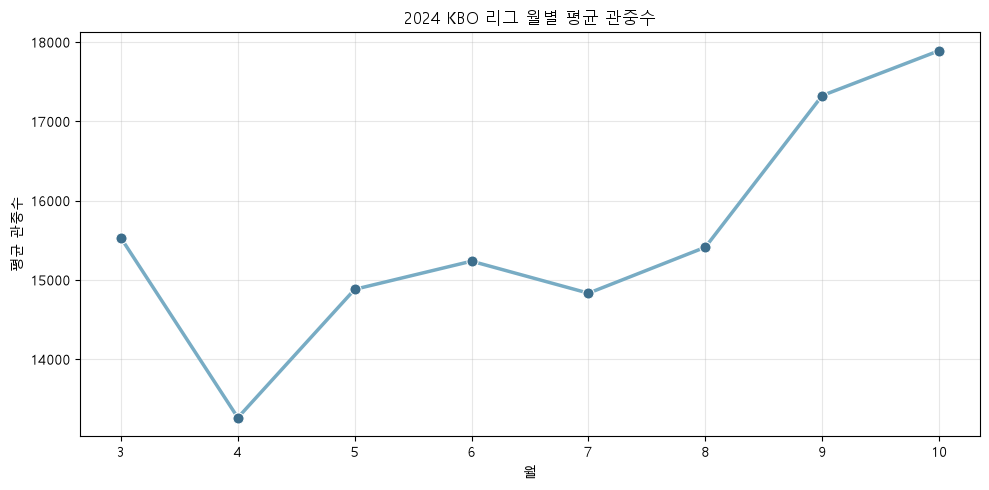

C:\Users\ahnny\AppData\Local\Temp\ipykernel_1836\3084748747.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='시기', y='관중수', order=period_order,


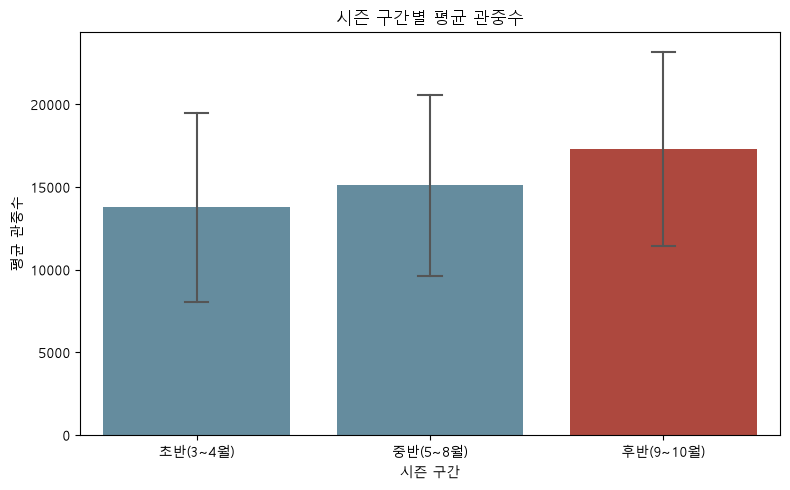

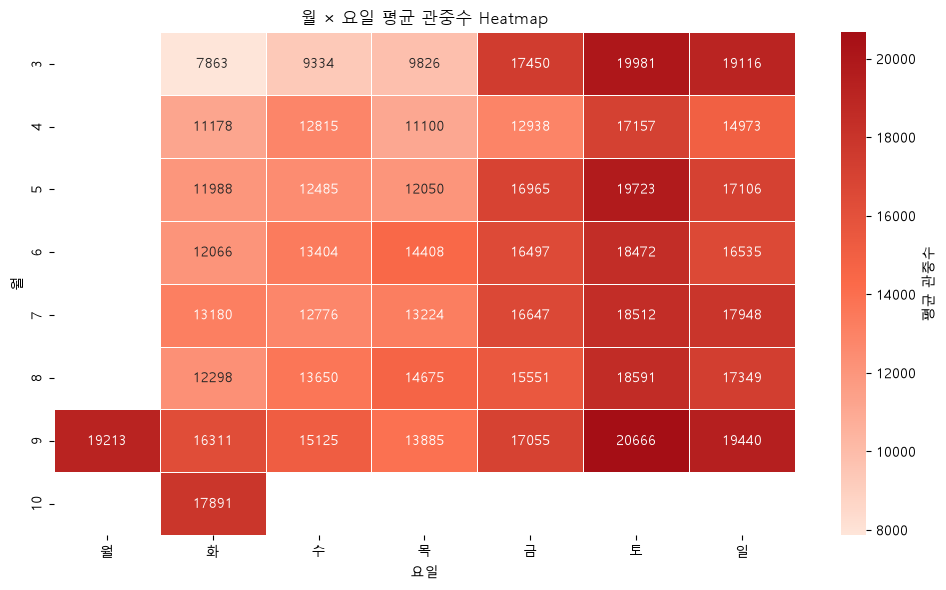

In [19]:
from matplotlib.colors import LinearSegmentedColormap

# 1. 월별 평균 관중수: Line Plot
monthly_avg = df.groupby('월')['관중수'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_avg, x='월', y='관중수', marker='o',
             color="#78ACC4", linewidth=2.5, markersize=8,
             markerfacecolor='#3D6E8C', markeredgecolor='white')
plt.title('2024 KBO 리그 월별 평균 관중수')
plt.xlabel('월')
plt.ylabel('평균 관중수')
plt.xticks(range(3, 11)) 
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2. 시즌 구간별 평균 관중수: Bar Plot 
def get_period(month):
    if month in [3, 4]:
        return '초반(3~4월)'
    elif month in [5, 6, 7, 8]:
        return '중반(5~8월)'
    elif month in [9, 10]:
        return '후반(9~10월)'
    else:
        return '기타'

df['시기'] = df['월'].apply(get_period)

period_order = ['초반(3~4월)', '중반(5~8월)', '후반(9~10월)']

period_means = df.groupby('시기')['관중수'].mean().reindex(period_order)
max_period = period_means.idxmax()

colors = ['#C0392B' if p == max_period else '#5B8FA8' for p in period_order]
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='시기', y='관중수', order=period_order,
            palette=colors, errorbar='sd',
            err_kws={'linewidth': 1.5, 'color': '#555555'},
            capsize=0.1)
plt.title('시즌 구간별 평균 관중수')
plt.xlabel('시즌 구간')
plt.ylabel('평균 관중수')
plt.tight_layout()
plt.show()


# 3. 월 × 요일 Heatmap
weekday_order = ['월', '화', '수', '목', '금', '토', '일']

pivot = df.pivot_table(index='월', columns='요일', values='관중수', aggfunc='mean')
pivot = pivot[weekday_order] 

custom_cmap = LinearSegmentedColormap.from_list(
    'custom_red', ['#fee5d9', '#fb6a49', '#a50e15']
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap=custom_cmap, linewidths=0.5,
            linecolor='white', cbar_kws={'label': '평균 관중수'})
plt.title('월 × 요일 평균 관중수 Heatmap')
plt.xlabel('요일')
plt.ylabel('월')
plt.tight_layout()
plt.show()

# (2024년) KBO 리그 관중수 추이 분석

## 1. 분석 질문
- KBO 리그 관중수는 시즌 진행 시기와 요일에 따라 어떻게 달라지는가?

## 2. 수집 대상
- 출처: https://www.koreabaseball.com/
- 조건: 2024년 KBO 리그 전체 경기 (총 720경기)
- 필요 컬럼: 경기 날짜, 요일, 홈팀, 방문(원정)팀, 구장, 관중수

## 3. 수집 방법
- 도구: 클로드 코드(insane-research)
- 사용 방식: requests + BeautifulSoup
- robots.txt 확인 후 허용된 경로만 수집, 요청 간 time.sleep(1~2초) 적용, User-Agent 헤더 명시

## 4. 데이터 정제
- 관중수: 콤마 제거 후 문자열 → 정수 변환
- 날짜: 문자열 → datetime 변환
- 월 컬럼 파생
- 결측치 없음 (720행 확인, 2024시즌 정규경기 수와 일치)

## 5. 주요 분석 결과
- 월별 평균 관중수  
: 3월 이후 4월에 평균 관중수가 감소했으며, 이후 점진적으로 증가해 9~10월에 최고치를 기록했다. 3월의 높은 수치는 개막 시즌 효과, 7월의 일시적 감소는 올스타 브레이크 및 여름철 영향일 가능성이 있다.

-  시즌 구간별 평균 관중수  
: 시즌이 진행될수록 평균 관중 수가 증가했으며, 후반(9~10)이 가장 높았다. 이는 포스트시즌 진출을 위한 막판 순위 경쟁의 영향으로 추정된다. 세 구간의 표준편차가 유사해 관중수 증가가 일부 경기에 몰린 것이 아닌 시즌 전반에 걸쳐 나타난 것으로 보인다.

- 월 × 요일 평균 관중수  
: 요일별로는 주말경기(금~일) 관중수가 평일보다 꾸준히 높았으며, 시즌 후반으로 갈수록 평일과 주말 구분 없이 전반적인 관중수 상승이 관찰되었다.

## 6. 한계와 후속 작업
- 단일 시즌 데이터만 사용했기 때문에 발견된 패턴이 일반적인 추이인지 확인할 수 없다. → 몇 년치 데이터 추가 확보 필요
- 월별 관중수 차이의 원인(계절/날씨, 순위 경쟁 흥미도, 여름 휴가철 등)이 혼재되어 있어 이 데이터만으로는 요인을 분리하기 어렵다.
- 리그 전체 집계이므로 특정 월에 인기팀 홈경기가 몰려있으면 해당 월 평균이 왜곡될 수 있다. → 홈팀별 월간 경기 분포를 통해 검증 필요